***Devoir à la maison 1: Random Walk***  
Membres du groupe: Alfa Narcisse  - Alban Brice    - Abdo Abderrahmane  
Sujet: Marche aléatoire 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
#===================================================================
# Comùputing the probability using simulation approach
#===================================================================

def random_walk(n_steps, p=0.7):
    # p = probabilité de +1, (1-p) = probabilité de -1
    steps = np.random.choice([1, -1], size=n_steps, p=[p, 1-p])
    position = np.cumsum(steps)
    return position

In [8]:
n_simulations = 100000  # suffisamment grand pour appliquer la loi des grands nombre
n_steps = 100
n_realisation = 0
for _ in range (n_simulations):
    p_i = random_walk(n_steps,0.7)
    if 35 <= p_i[-1]<= 45:
        n_realisation  += 1


print("Nombre de réalisation de l'événement: ", n_realisation)
print("La    probabilité de l'événement est: ", n_realisation/ n_simulations)

Nombre de réalisation de l'événement:  41526
La    probabilité de l'événement est:  0.41526


In [4]:
#=========================================================
# Calcul de la probabilité exacte utilisant la probabilité
#=========================================================
import math

def proba_x(x_n, n_steps=100, p=0.7):
    # x_n et n_steps doivent avoir la même parité (sinon x_n est inatteignable)
    if (n_steps + x_n) % 2 != 0:
        return 0
    # x_n doit être dans l'intervalle [-n_steps, n_steps]
    if abs(x_n) > n_steps:
        return 0
    
    k = (n_steps + x_n) // 2  # nombre de pas +1
    return math.comb(n_steps, k) * p**k * (1 - p)**(n_steps - k)

In [5]:
p = 0
for i in range(35,46):
    p += proba_x(i)

print("La probabilité de l'événement est: ", p)

La probabilité de l'événement est:  0.41435239574990446


Les deux approches nous donne deux résultats identiques à deux chiffres après virgule près. La probabilité qu'au 100th étape, on se trouve à une position entre 35 et 45 de l'origine est de 0.414352(valeur exacte) et de 0.41526 par la simulation

C:\Users\lenovo\AppData\Local\Temp\ipykernel_9660\1921885688.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


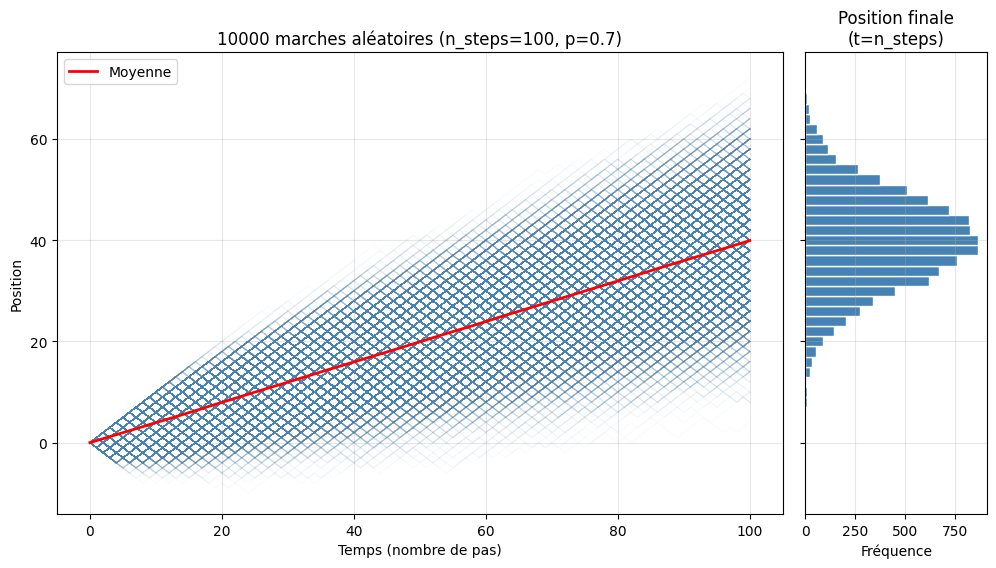

Moyenne empirique position finale : 39.9268
Écart-type empirique : 9.203881885378582


In [7]:
#===============================================================
#Visualisation de la distribution au dérnier step
#===============================================================

# --- Paramètres ---
n_steps = 100
n_simulations = 10000
p = 0.7  # proba de +1

# --- Simulation vectorisée ---
# steps : matrice (n_simulations x n_steps) de +1/-1
steps = np.random.choice([1, -1], size=(n_simulations, n_steps), p=[p, 1 - p])
trajectoires = np.cumsum(steps, axis=1)  # (n_simulations x n_steps)

# On ajoute la position initiale (0) à t=0 pour chaque trajectoire
trajectoires = np.hstack([np.zeros((n_simulations, 1)), trajectoires])
positions_finales = trajectoires[:, -1]

# --- Figure : trajectoires (temps en x) + histogramme vertical à droite ---
fig, (ax_traj, ax_hist) = plt.subplots(
    1, 2, figsize=(12, 6), sharey=True,
    gridspec_kw={"width_ratios": [4, 1], "wspace": 0.05}
)

# Trajectoires (chaque ligne = une simulation, très transparente)
temps = np.arange(n_steps + 1)
for i in range(n_simulations):
    ax_traj.plot(temps, trajectoires[i], color="steelblue", alpha=0.03, linewidth=0.8)

# Moyenne théorique/empirique en surimpression
ax_traj.plot(temps, trajectoires.mean(axis=0), color="red", linewidth=2, label="Moyenne")

ax_traj.set_xlabel("Temps (nombre de pas)")
ax_traj.set_ylabel("Position")
ax_traj.set_title(f"{n_simulations} marches aléatoires (n_steps={n_steps}, p={p})")
ax_traj.legend()
ax_traj.grid(alpha=0.3)

# Histogramme vertical (horizontal bars) des positions finales
bins = np.arange(positions_finales.min() - 1, positions_finales.max() + 2, 2)
ax_hist.hist(positions_finales, bins=bins, orientation="horizontal",
             color="steelblue", edgecolor="white")
ax_hist.set_xlabel("Fréquence")
ax_hist.set_title("Position finale\n(t=n_steps)")
ax_hist.grid(alpha=0.3)

plt.tight_layout()
plt.show()


print("Moyenne empirique position finale :", positions_finales.mean())
print("Écart-type empirique :", positions_finales.std())

La graphe ci-dessus nous montre qu'à l'étape 100, la distribution de X100 est bel shaped, il suit, donc, approximativement, la loi normale.